For performing new tracing first import and make Tracer object based on config file settings.
The config file contains locations of images and ROIs for tracing, as well as settings for tracing, quality control and data output and saving.

In [1]:
from tracer import Tracer
import tracing_functions as tr
T=Tracer(r"M:\ChromatinTeam\Images_processing\20200521_Exp328_KSB_Elyra_lowres_A565_bleach_robot\20200523_Exp_328_tracing_config.yaml")
T_beads=Tracer(r"M:\ChromatinTeam\Images_processing\20200521_Exp328_KSB_Elyra_lowres_A565_bleach_robot\20200523_Exp_328_tracing_config_beads.yaml")

If the analysis has already been run before, we can load the data instead:

In [3]:
import pandas as pd
import numpy as np
import os
import image_processing_functions as ip
wdir = r"M:\ChromatinTeam\Images_processing\20200521_Exp328_KSB_Elyra_lowres_A565_bleach_robot\03_Analysis"+os.sep
traces = pd.read_hdf(wdir+"20200521_Exp328_ELYRA_BS32-40_bleach_traces.h5")
imgs=np.moveaxis(ip.read_tif_image(wdir+'20200521_Exp328_ELYRA_BS32-40_bleach_imgs.tiff'),1,2)
traces_beads = pd.read_hdf(wdir+"20200521_Exp328_ELYRA_BS32-40_beads_traces_beads.h5")
imgs_beads=np.moveaxis(ip.read_tif_image(wdir+'20200521_Exp328_ELYRA_BS32-40_beads_imgs_beads.tiff'),1,2)

Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [4]:
traces.head()
traces.query('trace_ID == 40')

BG            A  \
trace_ID img_name               roi_ID cell_ID frame                            
40       seq_run_DE_2_W0007__dc 6      6       0      346.624191  1961.107374   
                                               1      151.130340   293.211057   
                                               2      153.386791   287.957426   
                                               3      155.704928   265.155403   
                                               4      140.263961   661.409289   
                                               5      141.416101   449.488328   
                                               6      142.975513   352.107571   
                                               7      118.317547   180.951998   
                                               8      293.890936   791.877156   
                                               9      192.020721   403.197080   

                                                           z_px       y_px  \
trace_ID img_name               roi_ID cell_ID frame                         
40       seq_run_DE_2_W0007__dc 6      6       0       8.167658  32.741610   
                                               1       7.539790  33.429558   
                                               2       7.792262  30.496679   
                                               3       8.148885  32.580451   
                                               4       8.579235  31.464534   
                                               5      10.138404  33.417434   
                                               6       8.664490  30.879993   
                                               7       9.477999  32.657817   
                                               8       9.245894  32.194661   
                                               9       8.305444  31.523752   

                                                           x_px     sigma_z  \
trace_ID img_name               roi_ID cell_ID frame                          
40       seq_run_DE_2_W0007__dc 6      6       0      32.228512  258.906239   
                                               1      30.960800  281.085597   
                                               2      28.938578  314.510002   
                                               3      31.614538  277.426934   
                                               4      30.450268  259.084356   
                                               5      29.970942  301.979997   
                                               6      30.200414  269.271644   
                                               7      31.576021  261.265656   
                                               8      30.993392  398.680152   
                                               9      30.814496  318.272447   

                                                        sigma_xy            z  \
trace_ID img_name               roi_ID cell_ID frame                            
40       seq_run_DE_2_W0007__dc 6      6       0      113.159030  1633.531629   
                                               1      115.399568  1507.958002   
                                               2      130.180085  1558.452463   
                                               3      117.857290  1629.777086   
                                               4      108.542013  1715.847084   
                                               5      115.495873  2027.680708   
                                               6      113.868502  1732.897966   
                                               7      104.290472  1895.599772   
                                               8      184.685628  1849.178856   
                                               9      156.786450  1661.088770   

                                                                y  \
trace_ID img_name               roi_ID cell_ID frame                
40       seq_run_DE_2_W0007__dc 6      6       0      3372.385831   
                       

We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

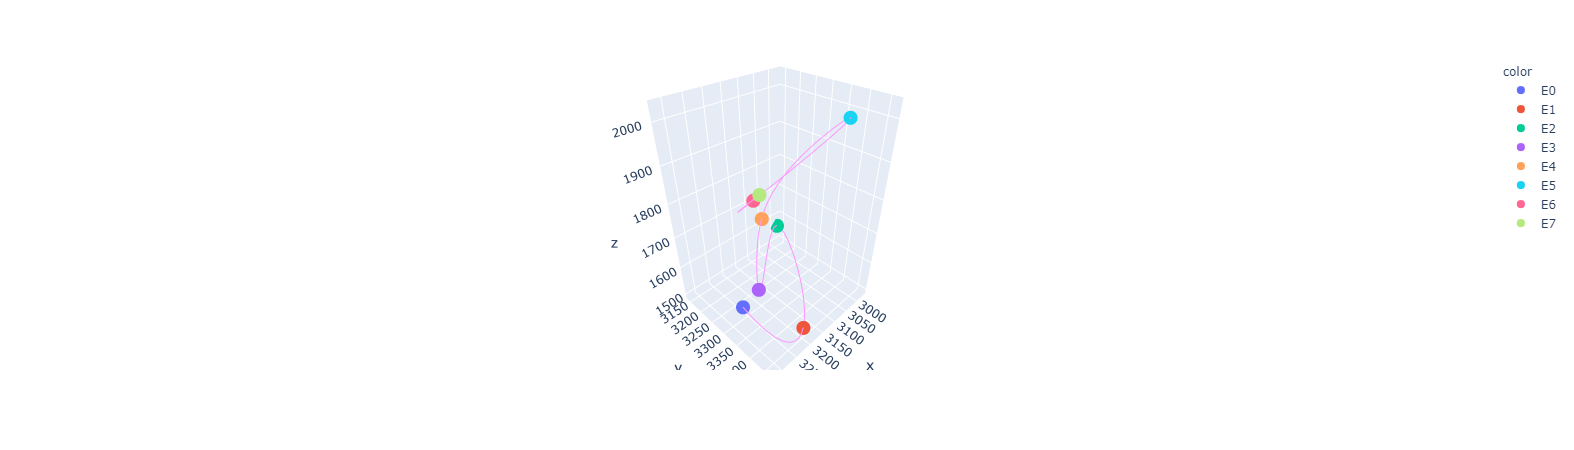

In [8]:
tr.plot_traces(traces,[40])

Let us get some more statistics on our traces:

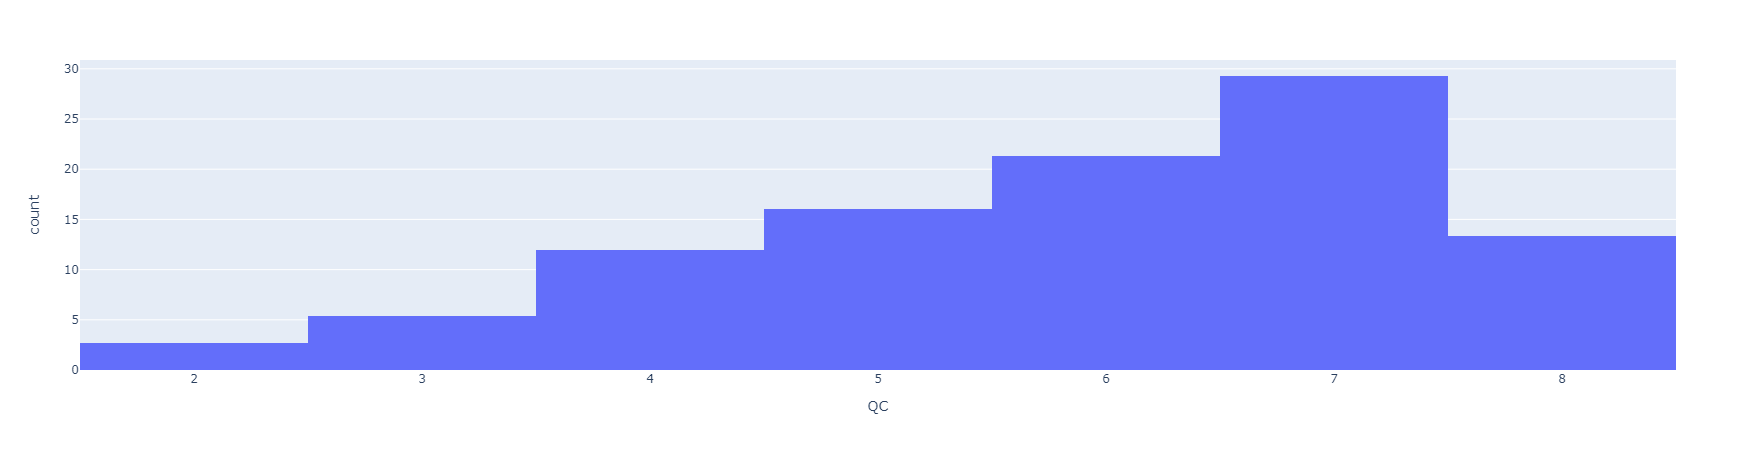

In [22]:
import plotly.express as px
px.histogram(traces.groupby(level='trace_ID').sum(), x='QC', histnorm='percent', width=100)

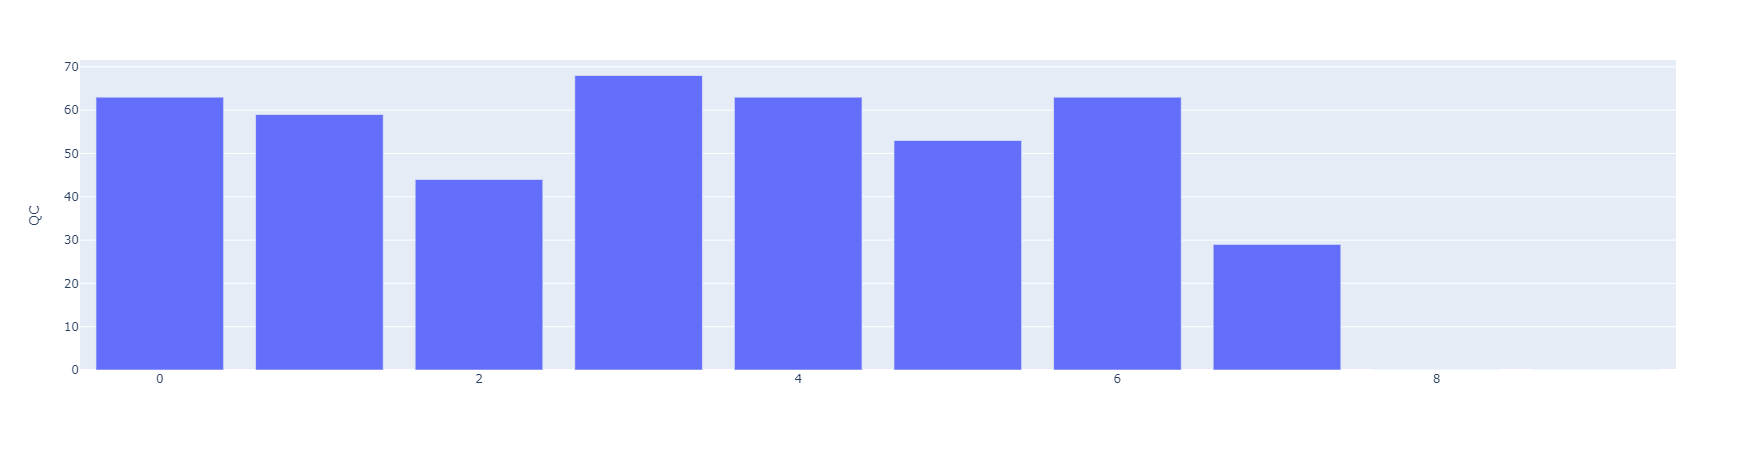

In [35]:
px.bar(traces.groupby(level='frame').sum(), y='QC')

In [38]:
[print('Traces with exchanges: ', i, (traces.groupby(level='trace_ID').sum()['QC']>i).sum()) for i in range(8)]

Traces with exchanges:  0 75
Traces with exchanges:  1 75
Traces with exchanges:  2 73
Traces with exchanges:  3 69
Traces with exchanges:  4 60
Traces with exchanges:  5 48
Traces with exchanges:  6 32
Traces with exchanges:  7 10


[None, None, None, None, None, None, None, None]

Visualize fits on top of actual image data using napari.

In [40]:
import napari
points=tr.points_for_overlay(traces.query('QC==1'))
with napari.gui_qt():
    viewer = napari.view_image(np.max(imgs,axis=2), contrast_limits=(100,1000))
    viewer.add_points(points[:,(0,1,3,4)], size=[0,0,1,1], face_color='blue', symbol='cross', n_dimensional=True)

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [43]:
traces_long = tr.tracing_length_qc(traces, min_length=7)
pwds_long = tr.pwd_calc(traces_long)

Number of traces in analysis:  32


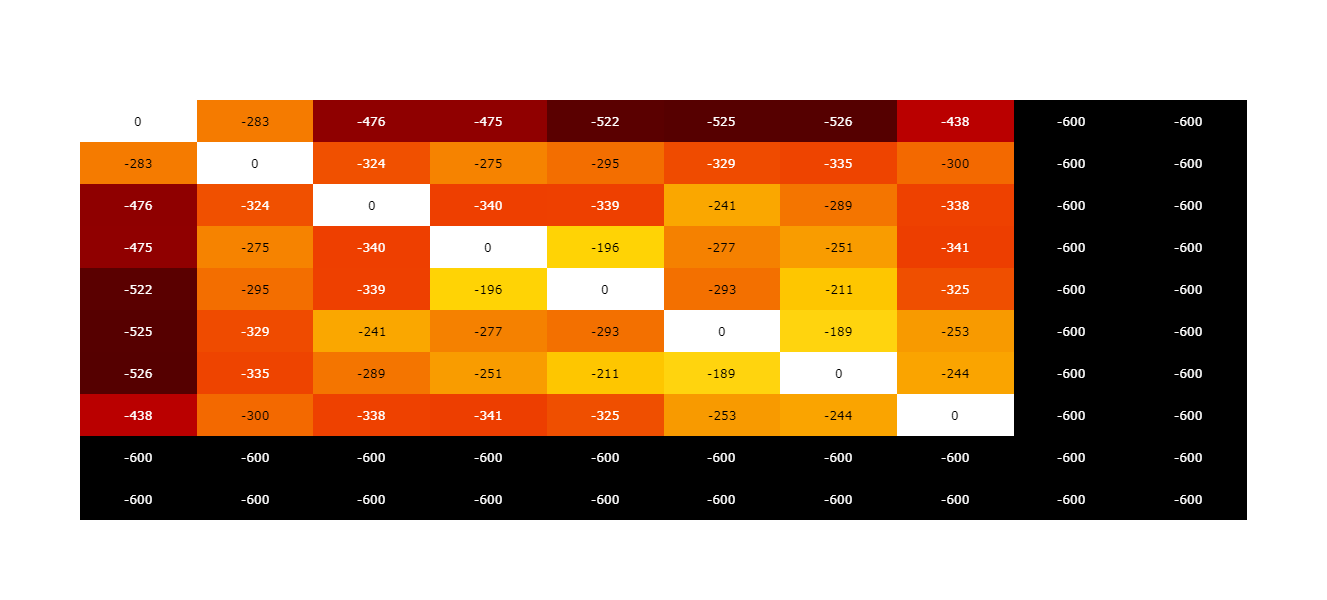

In [44]:
print('Number of traces in analysis: ', pwds_long.shape[0])
pwds_mean=np.clip(np.round(-np.nanmedian(pwds_long, axis=0),0).astype(int),-600,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [49]:
pairs = tr.trace_analysis(traces_long, pwds_long)
pairs.sort_values(by=['aligned_mse'], ascending=True).head()

,idx1,idx2,A,A_idx,B,B_idx,B_aligned,B_aligned_idx,aligned_mse,pwd_mse,pwd_pcc
125,10,33,"[[2889.7823566009115, 3546.965565352271, 1176....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3276.810789239976, 3243.612262032371, 1104.9...","Int64Index([1, 2, 3, 4, 5, 6, 7], dtype='int64...","[[3364.8371170063224, 3275.233518813742, 1068....","Int64Index([1, 2, 3, 4, 5, 6, 7], dtype='int64...",2850.070945,8858.944729,0.491724
302,32,67,"[[3490.47004636441, 3223.4502245523013, 1482.9...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3281.270511877594, 3417.0822652680567, 1084....","Int64Index([0, 1, 2, 3, 4, 6, 7], dtype='int64...","[[3556.403251019511, 3265.4818862329, 1466.966...","Int64Index([0, 1, 2, 3, 4, 6, 7], dtype='int64...",3439.237476,12887.619060,0.698730
351,43,59,"[[3235.858656408096, 3072.8431388738995, 1750....","Int64Index([0, 1, 3, 4, 5, 6, 7], dtype='int64...","[[3072.0941431196156, 3345.497756207845, 1633....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3186.505194646698, 3069.7106058036634, 1745....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...",3733.398366,6241.939901,0.529479
316,33,59,"[[3276.810789239976, 3243.612262032371, 1104.9...","Int64Index([1, 2, 3, 4, 5, 6, 7], dtype='int64...","[[3072.0941431196156, 3345.497756207845, 1633....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3164.079532370795, 3412.3685989018754, 1135....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...",4325.531749,7180.718392,0.438554
466,59,70,"[[3072.0941431196156, 3345.497756207845, 1633....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3149.6753608389176, 3247.523389051668, 1364....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3167.630957855507, 3264.774615946873, 1618.0...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...",4813.787945,7556.448704,0.631712


We can visualize the aligned traces by their index in the pair matrix.

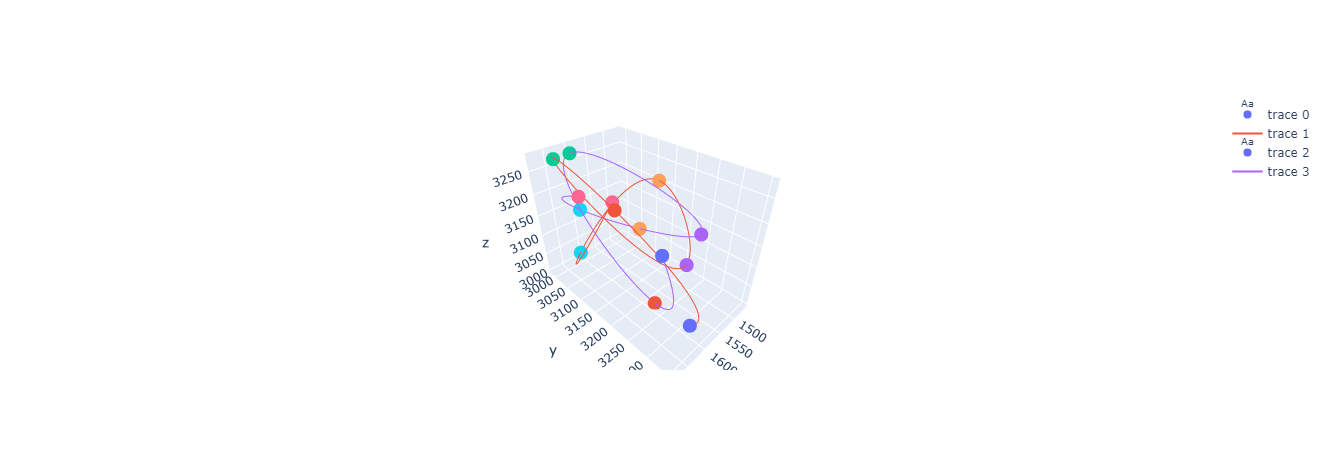

In [51]:
tr.plot_paired_traces(pairs, 466)

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

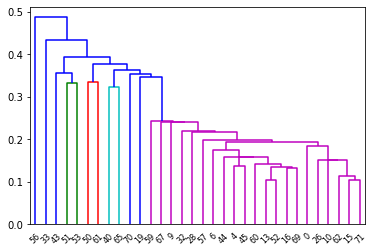

In [48]:
Z = tr.trace_clustering(pairs, metric='pwd_pcc')

We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.